In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\Soham\Desktop\Adult Income Data Cleaning and EDA\src\clean_income_data.csv")
df

,Age,Work_class,Fnlwgt,Education,Education_Num,Marital_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_Per_Week,Native_Country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,50K or Less
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,50K or Less
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,50K or Less
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,50K or Less
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,50K or Less
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,50K or Less
48838,64,Private,321403,HS-grad,9,Widowed,Prof-specialty,Other-relative,Black,Male,0,0,40,United-States,50K or Less
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,50K or Less
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,50K or Less


In [3]:
df['high_income'] = (df['Income'] == 'Above 50K').astype(int)

print(df['high_income'].value_counts())

high_income
0    37155
1    11687
Name: count, dtype: int64


In [4]:
print(df['Income'].unique())
print(df['Income'].value_counts())


['50K or Less' 'Above 50K']
Income
50K or Less    37155
Above 50K      11687
Name: count, dtype: int64


In [5]:
df

,Age,Work_class,Fnlwgt,Education,Education_Num,Marital_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_Per_Week,Native_Country,Income,high_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,50K or Less,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,50K or Less,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,50K or Less,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,50K or Less,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,50K or Less,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,50K or Less,0
48838,64,Private,321403,HS-grad,9,Widowed,Prof-specialty,Other-relative,Black,Male,0,0,40,United-States,50K or Less,0
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,50K or Less,0
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,50K or Less,0


C:\Users\Soham\AppData\Local\Temp\ipykernel_17848\2896679280.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


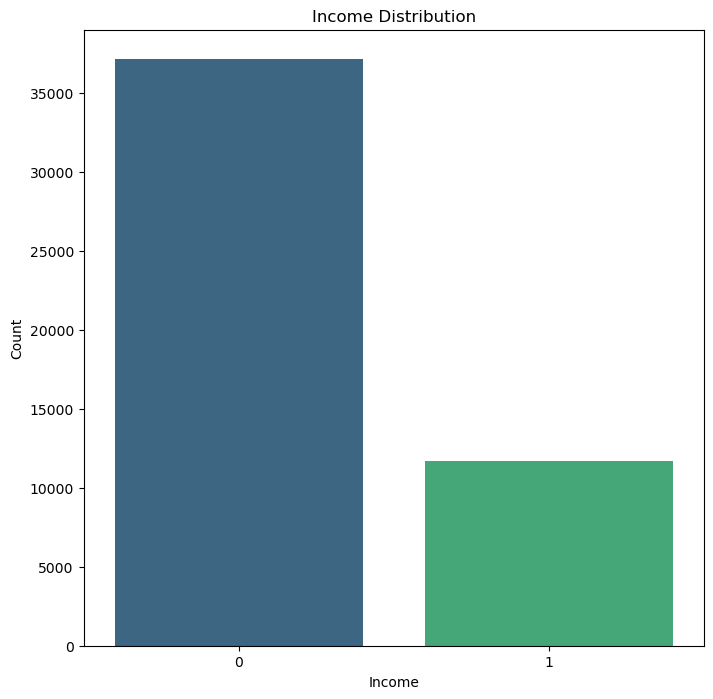

In [6]:
# 1. Income Distribution

plt.figure(figsize=(8, 8))

income_rate = df['high_income'].value_counts()

sns.barplot(
    x=income_rate.index,
    y=income_rate.values,
    palette='viridis'
)

plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Count')

plt.savefig('../reports/charts/1. income_distribution.png')

plt.show()

C:\Users\Soham\AppData\Local\Temp\ipykernel_17848\4002026544.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


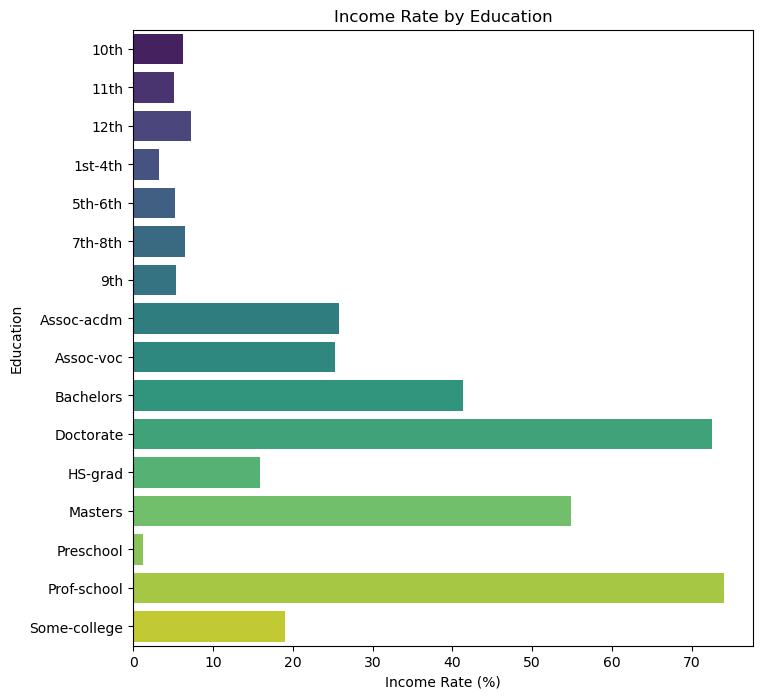

In [7]:
# 2. Income Rate by Education

plt.figure(figsize=(8, 8))

education_rate = df.groupby('Education')['high_income'].mean() * 100

sns.barplot(
    x=education_rate.values,
    y=education_rate.index,
    palette='viridis'
)

plt.title('Income Rate by Education')
plt.xlabel('Income Rate (%)')
plt.ylabel('Education')

plt.savefig('../reports/charts/2. income_rate_by_education.png')

plt.show()

In [8]:
df.columns

Index(['Age', 'Work_class', 'Fnlwgt', 'Education', 'Education_Num',
       'Marital_Status', 'Occupation', 'Relationship', 'Race', 'Sex',
       'Capital_Gain', 'Capital_Loss', 'Hours_Per_Week', 'Native_Country',
       'Income', 'high_income'],
      dtype='object')

C:\Users\Soham\AppData\Local\Temp\ipykernel_17848\3320308818.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(


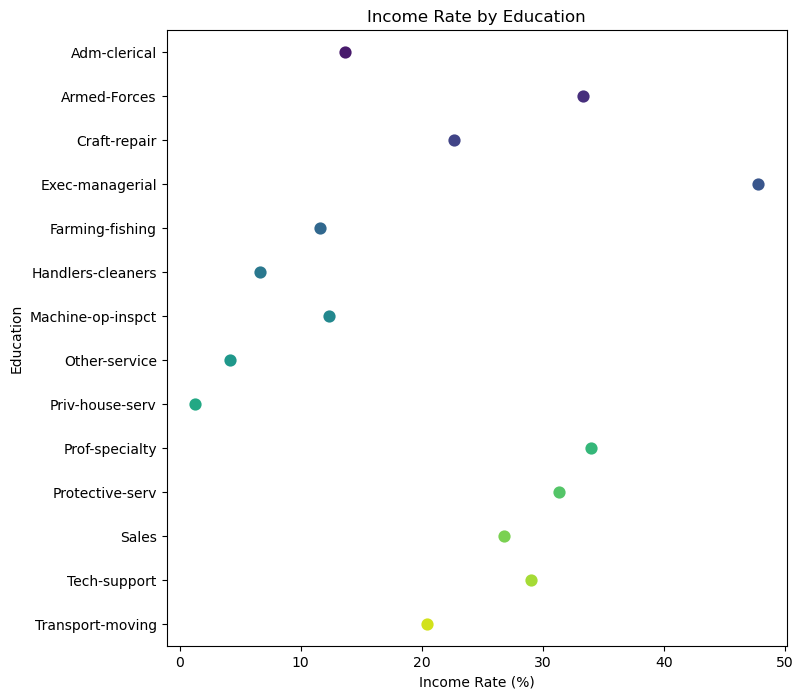

In [9]:
# 3 Income Rate by Occupation

plt.figure(figsize=(8, 8))

# Calculate income rate
education_rate = df.groupby('Occupation')['high_income'].mean() * 100

# Create plot
sns.pointplot(
    x=education_rate.values,
    y=education_rate.index,
    palette='viridis'
)

plt.title('Income Rate by Education')
plt.xlabel('Income Rate (%)')
plt.ylabel('Education')

plt.savefig('../reports/charts/3. income_rate_by_occupation.png')

plt.show()


C:\Users\Soham\AppData\Local\Temp\ipykernel_17848\663327288.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


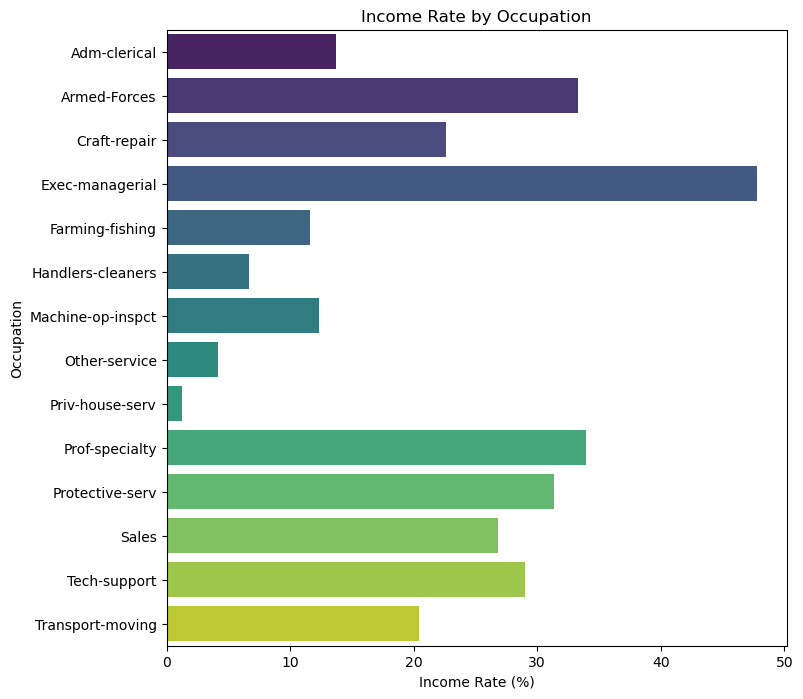

In [10]:
# 4. Income Rate by Occupation

plt.figure(figsize=(8, 8))

occupation_rate = df.groupby('Occupation')['high_income'].mean() * 100

sns.barplot(
    x=occupation_rate.values,
    y=occupation_rate.index,
    palette='viridis'
)

plt.title('Income Rate by Occupation')
plt.xlabel('Income Rate (%)')
plt.ylabel('Occupation')

plt.savefig('../reports/charts/4. income_rate_by_occupation.png')

plt.show()

C:\Users\Soham\AppData\Local\Temp\ipykernel_17848\706502151.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


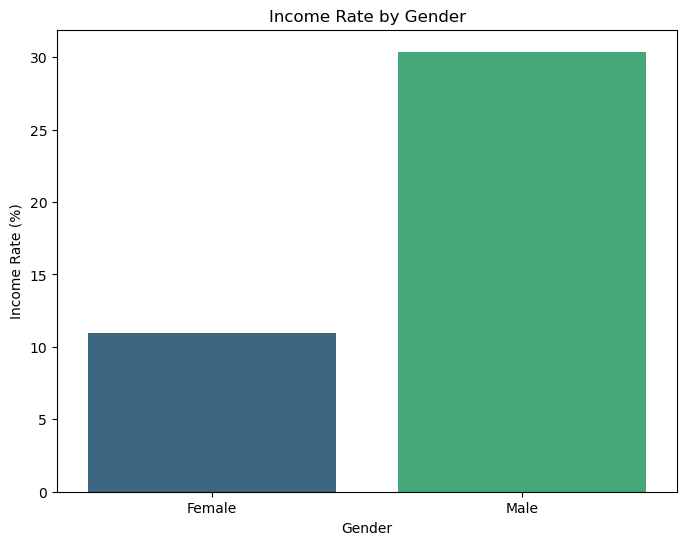

In [11]:
# 5. Income Rate by Gender

plt.figure(figsize=(8, 6))

gender_rate = df.groupby('Sex')['high_income'].mean() * 100

sns.barplot(
    x=gender_rate.index,
    y=gender_rate.values,
    palette='viridis'
)

plt.title('Income Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Income Rate (%)')

plt.savefig('../reports/charts/5. income_rate_by_gender.png')

plt.show()

C:\Users\Soham\AppData\Local\Temp\ipykernel_17848\968023837.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


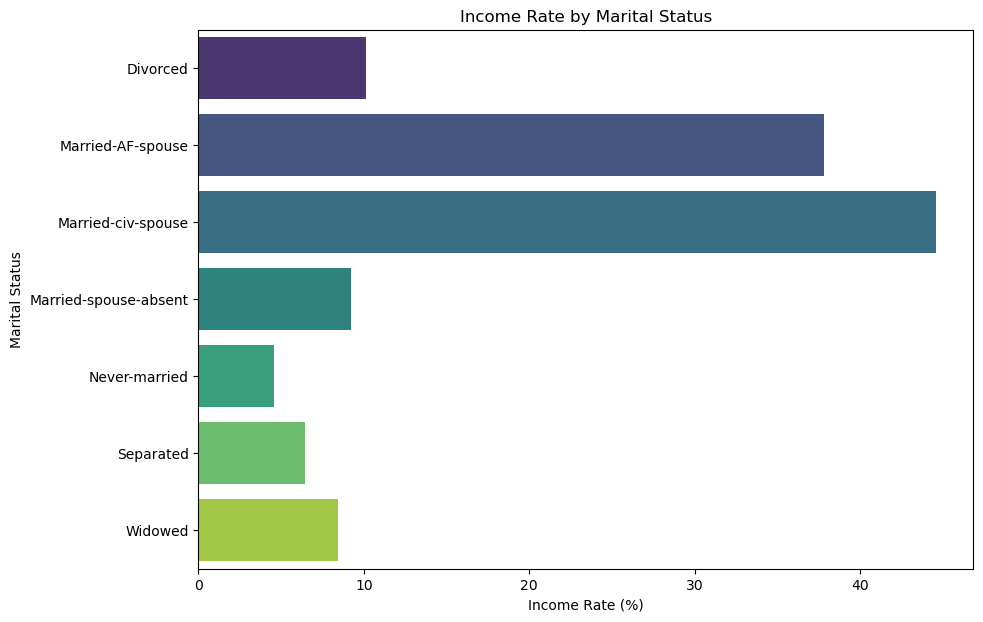

In [12]:
# 6. Income Rate by Marital Status

plt.figure(figsize=(10, 7))

marital_rate = df.groupby('Marital_Status')['high_income'].mean() * 100

sns.barplot(
    x=marital_rate.values,
    y=marital_rate.index,
    palette='viridis'
)

plt.title('Income Rate by Marital Status')
plt.xlabel('Income Rate (%)')
plt.ylabel('Marital Status')

plt.savefig('../reports/charts/6. income_rate_by_marital_status.png')

plt.show()

C:\Users\Soham\AppData\Local\Temp\ipykernel_17848\15882076.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


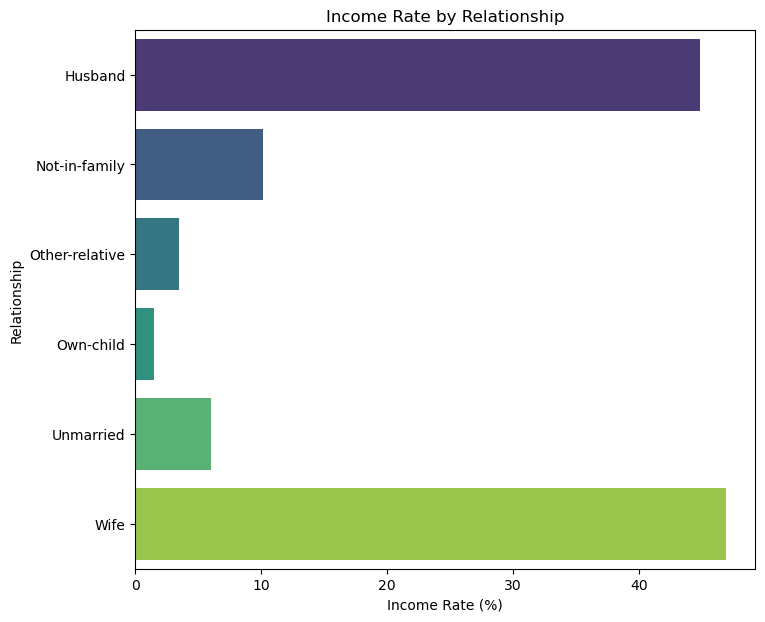

In [13]:
# 7. Income Rate by Relationship

plt.figure(figsize=(8, 7))

relationship_rate = df.groupby('Relationship')['high_income'].mean() * 100

sns.barplot(
    x=relationship_rate.values,
    y=relationship_rate.index,
    palette='viridis'
)

plt.title('Income Rate by Relationship')
plt.xlabel('Income Rate (%)')
plt.ylabel('Relationship')

plt.savefig('../reports/charts/7. income_rate_by_relationship.png')

plt.show()

C:\Users\Soham\AppData\Local\Temp\ipykernel_17848\3296459432.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


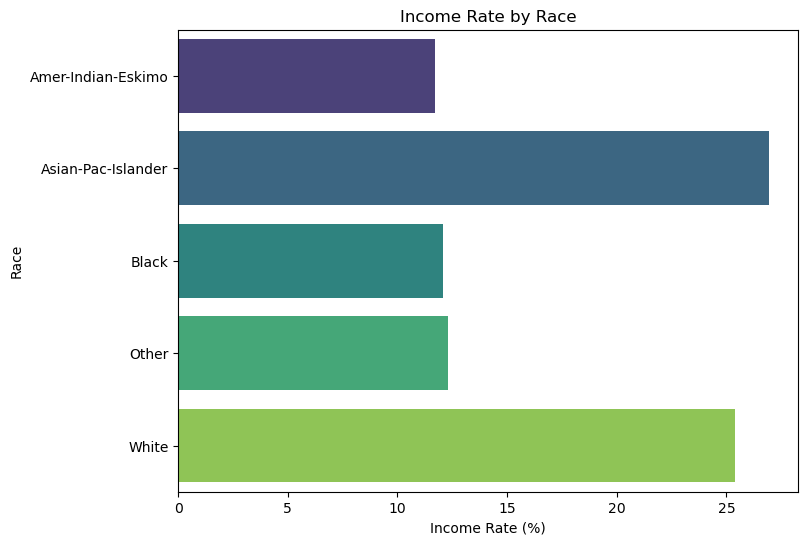

In [14]:
# 8. Income Rate by Race

plt.figure(figsize=(8, 6))

race_rate = df.groupby('Race')['high_income'].mean() * 100

sns.barplot(
    x=race_rate.values,
    y=race_rate.index,
    palette='viridis'
)

plt.title('Income Rate by Race')
plt.xlabel('Income Rate (%)')
plt.ylabel('Race')

plt.savefig('../reports/charts/8. income_rate_by_race.png')

plt.show()

C:\Users\Soham\AppData\Local\Temp\ipykernel_17848\3199363253.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


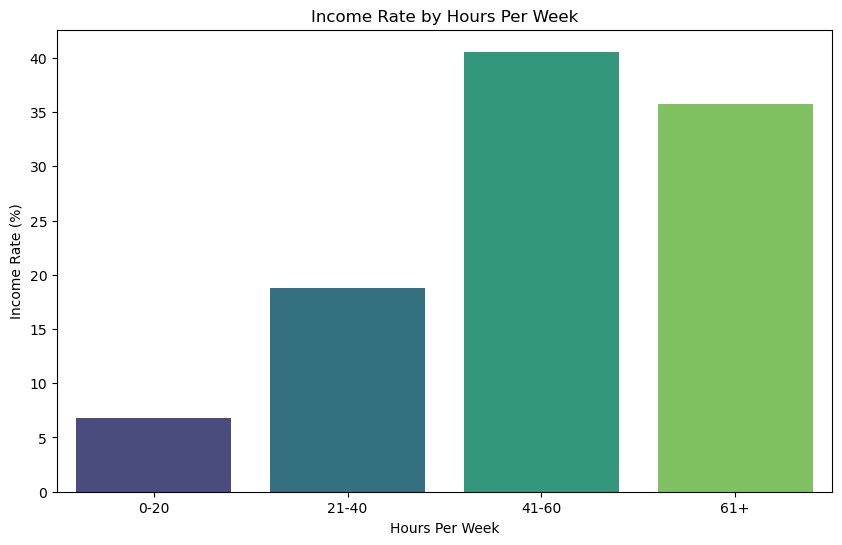

In [15]:
# 9. Income Rate by Hours Per Week

plt.figure(figsize=(10, 6))

df['hours_group'] = pd.cut(
    df['Hours_Per_Week'],
    bins=[0, 20, 40, 60, 100],
    labels=['0-20', '21-40', '41-60', '61+']
)

hours_rate = df.groupby('hours_group', observed=False)['high_income'].mean() * 100

sns.barplot(
    x=hours_rate.index,
    y=hours_rate.values,
    palette='viridis'
)

plt.title('Income Rate by Hours Per Week')
plt.xlabel('Hours Per Week')
plt.ylabel('Income Rate (%)')

plt.savefig('../reports/charts/9. income_rate_by_hours_per_week.png')

plt.show()

C:\Users\Soham\AppData\Local\Temp\ipykernel_17848\169769873.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


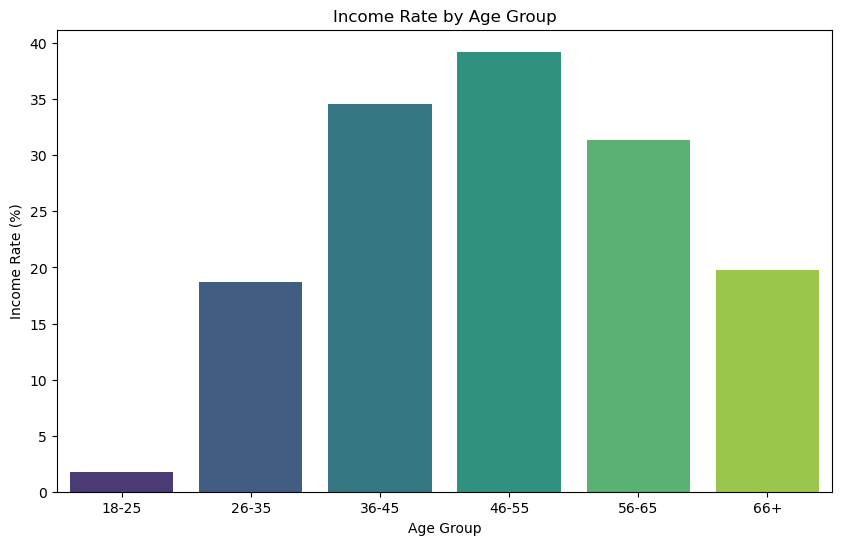

In [16]:
# 10. Income Rate by Age Group

plt.figure(figsize=(10, 6))

df['age_group'] = pd.cut(
    df['Age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
)

age_rate = df.groupby('age_group', observed=False)['high_income'].mean() * 100

sns.barplot(
    x=age_rate.index,
    y=age_rate.values,
    palette='viridis'
)

plt.title('Income Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Income Rate (%)')

plt.savefig('../reports/charts/10. income_rate_by_age_group.png')

plt.show()